<a href="https://colab.research.google.com/github/Nikil-Abbishak/Loan-Approval-ML-prediction/blob/main/ML_Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author - Nikil Abbishak

Peer Reviewer - Vipura Devnak

Notebook 2: Classification Modelling & Hyperparameter Tuning

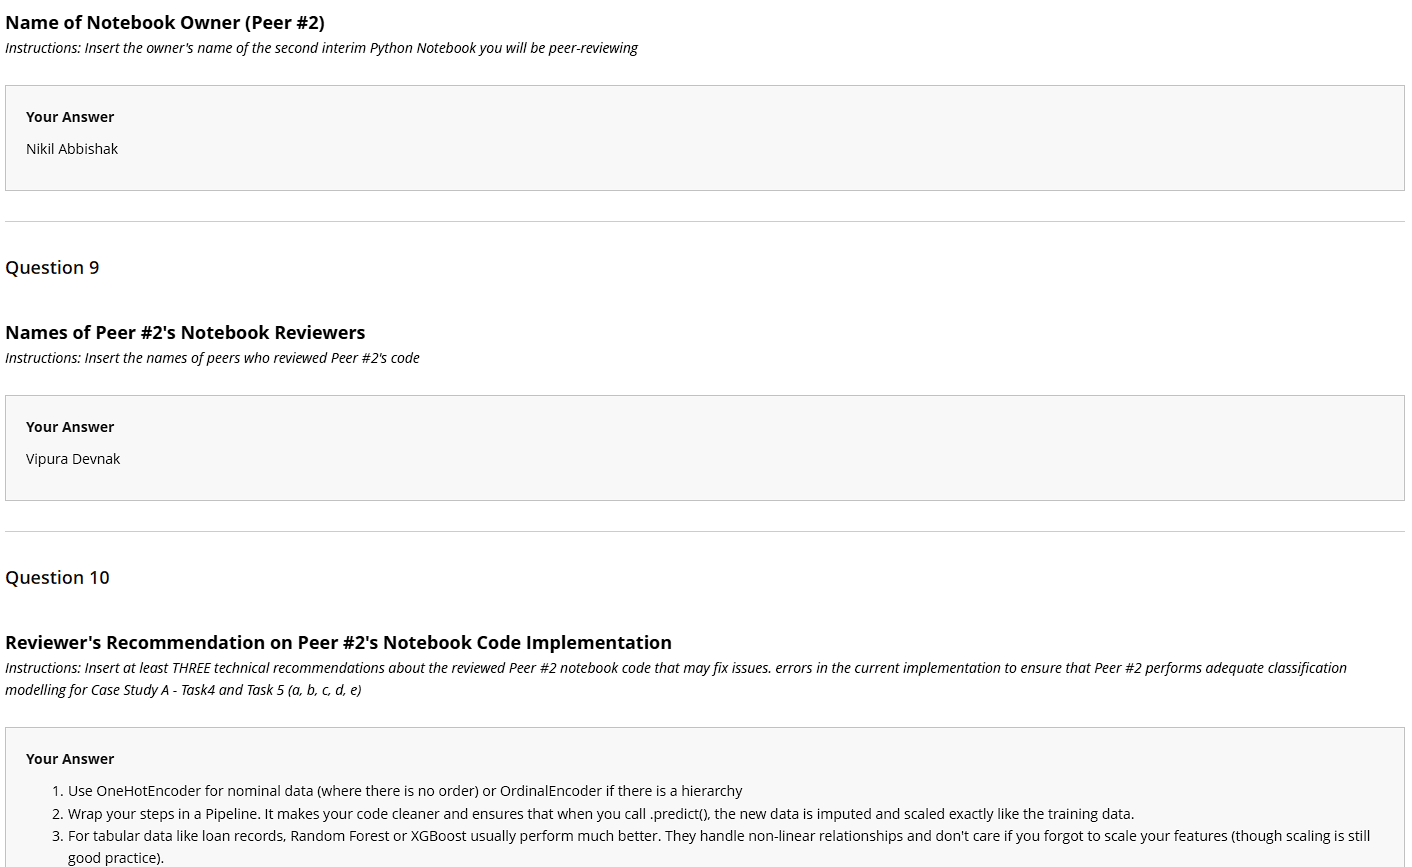

Section 1 - Import Libraries  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 3 / Tutorial 4.

In [ ]:
# Import pandas
import pandas as pd

# Import numpy
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

Section 2 - Load Classification Dataset  
Leveraged and reused from Coursework Code Reuse Session 2.

In [ ]:
# Load dataset created in Notebook 1
df = pd.read_csv('/content/drive/MyDrive/classification_dataset.csv')

# Display first rows
df.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,-2426900,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,-111739,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,-89000,False,False,True,False,False,True,False,False,False
3,40.0,182004,3,35000,8.00,0.19,11,0,35000,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,35000,False,False,False,False,True,False,False,False,False


In [ ]:
list(X.columns)

['age',
 'income',
 'emplyment_length',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'credit_history_length',
 'home_ownership_OTHER',
 'home_ownership_OWN',
 'home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'payment_default_on_file_Y']

Section 3 - Define Features and Target  
Leveraged and reused from Coursework Code Reuse Session 2.

In [ ]:
# Define input features
X = df.drop(['loan_approval_status', 'max_allowed_loan'], axis=1)

# Define target variable
y = df['loan_approval_status']

# Check shapes
X.shape, y.shape

((58644, 16), (58644,))

Section 4 - Train-Test Split  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 3.

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check sizes
X_train.shape, X_test.shape

((46915, 16), (11729, 16))

In [ ]:
pd.DataFrame({
    'Full Dataset': y.value_counts(normalize=True),
    'Training Set': y_train.value_counts(normalize=True),
    'Test Set': y_test.value_counts(normalize=True)
})

,Full Dataset,Training Set,Test Set
loan_approval_status,,,
0,0.857615,0.857615,0.857618
1,0.142385,0.142385,0.142382


Section 5 - Feature Scaling  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 3.


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test = scaler.transform(X_test)

Section 6 - Logistic Regression Model  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 3.

In [ ]:
# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

Section 7 - Naive Bayes Model  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 4.

In [ ]:
# Initialize Naive Bayes model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

# Predictions
y_pred_nb = nb.predict(X_test)

Section 8 - KNN Model  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 4.

In [ ]:
# Initialize KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

Section 9 - Model Evaluation  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 4.

In [ ]:
def evaluate_model(y_test, y_pred, model_name):

    print(f"\n{model_name} Performance")

    # Accuracy
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Classification report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()

Section 10 - Evaluating All Models


Logistic Regression Performance
Accuracy: 0.8959843123880978

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.73      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729


Naive Bayes Performance
Accuracy: 0.8211271208116634

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89     10059
           1       0.43      0.74      0.54      1670

    accuracy                           0.82     11729
   macro avg       0.69      0.79      0.72     11729
weighted avg       0.88      0.82      0.84     11729


KNN Performance
Accuracy: 0.9188336601585813

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059


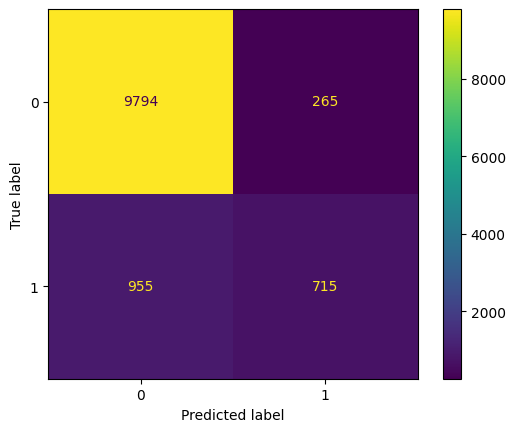

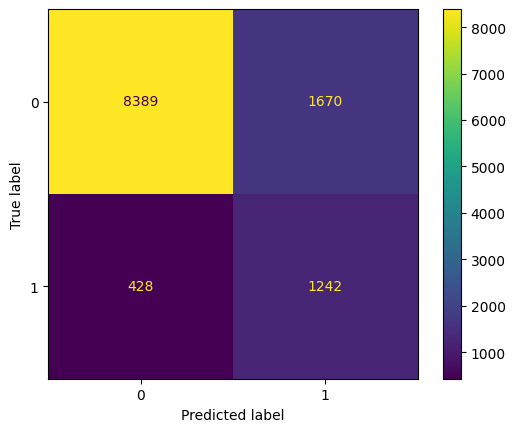

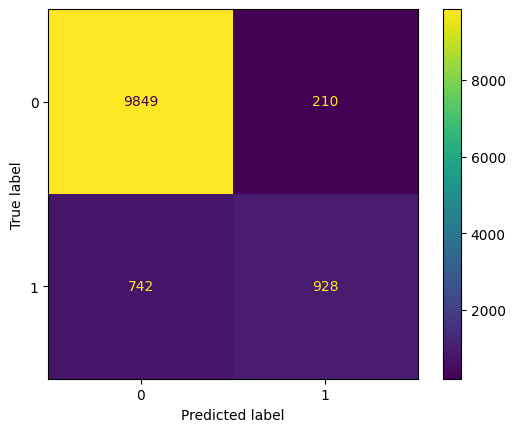

In [ ]:
# Evaluate Logistic Regression
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

# Evaluate Naive Bayes
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

# Evaluate KNN
evaluate_model(y_test, y_pred_knn, "KNN")

Section 11 - ROC Curve Analysis  
Leveraged and reused from Coursework Code Reuse Session 2.

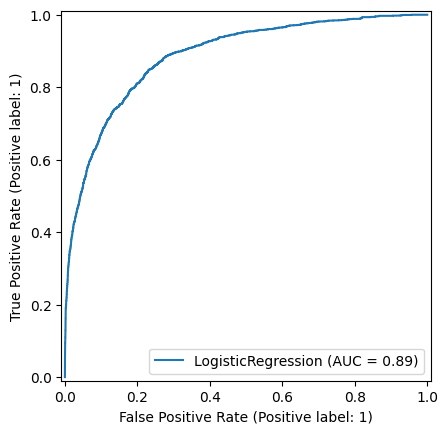

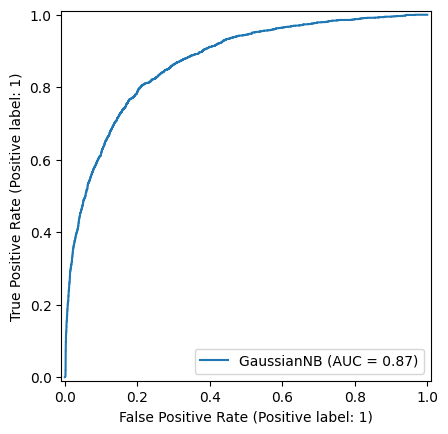

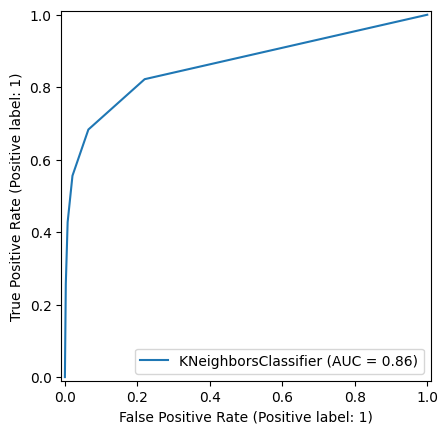

In [ ]:
# ROC for Logistic Regression
RocCurveDisplay.from_estimator(lr, X_test, y_test)

# ROC for Naive Bayes
RocCurveDisplay.from_estimator(nb, X_test, y_test)

# ROC for KNN
RocCurveDisplay.from_estimator(knn, X_test, y_test)

Section 12 - Hyperparameter Tuning using GridSearchCV  
Leveraged and reused from Coursework Code Reuse Session 2 / Tutorial 4.

In [ ]:
# Define parameter grid
param_grid = {'n_neighbors': [3,5,7,9,11]}

# Apply GridSearch
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

# Best parameters
grid.best_params_

{'n_neighbors': 5}

Section 13 - Evaluate Tuned Model


Tuned KNN Performance
Accuracy: 0.9188336601585813

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     10059
           1       0.82      0.56      0.66      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.77      0.81     11729
weighted avg       0.91      0.92      0.91     11729



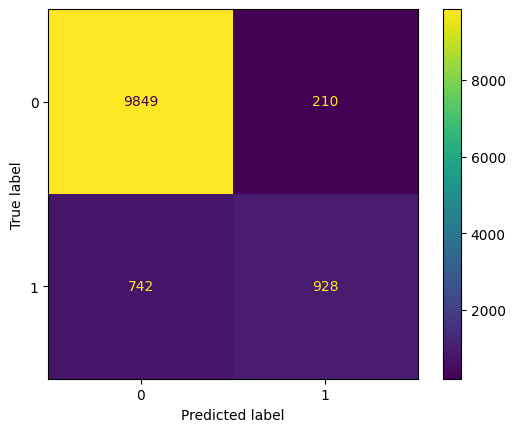

In [ ]:
# Predictions with best model
y_pred_tuned = grid.predict(X_test)

# Evaluate tuned model
evaluate_model(y_test, y_pred_tuned, "Tuned KNN")

In [ ]:
df.columns


Index(['age', 'income', 'emplyment_length', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'credit_history_length',
       'loan_approval_status', 'max_allowed_loan', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'payment_default_on_file_Y'],
      dtype='object')